<a href="https://colab.research.google.com/github/azaher1215/CSE573-Final-project/blob/main/CSE573_finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE 573 Final Project: Monocular Depth Estimation

Predict a dense depth map from a single RGB image using a CNN encoder–decoder.

**How to use:** Runtime → Change runtime type → GPU (we are using L4 GPU), then run all.


## 0. Setup — imports, mounting, donwloading the dataset

In [3]:

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "matplotlib", "pillow", "numpy"], check=False)

import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch 2.11.0+cu128 | CUDA available: True
GPU: NVIDIA L4


In [1]:
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/nyu_subset'

Mounted at /content/drive


### Downloading Dataset - Run once

In [ ]:
import os, urllib.request, h5py, numpy as np
from PIL import Image

DATA_ROOT = "/content/drive/MyDrive/nyu_subset"
os.makedirs(os.path.join(DATA_ROOT, "rgb"),   exist_ok=True)
os.makedirs(os.path.join(DATA_ROOT, "depth"), exist_ok=True)

# download the official labeled dataset
MAT = "/content/nyu_depth_v2_labeled.mat"
URL = "http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat"
if not os.path.exists(MAT):
    print("downloading, this takes a few minutes...")
    urllib.request.urlretrieve(URL, MAT)
    print("downloading done. Now starting preprocessing.")

# open it and read images, depths, and per-frame scene names
f = h5py.File(MAT, "r")
images, depths = f["images"], f["depths"]          # (1449,3,640,480), (1449,640,480)
scenes = ["".join(chr(c) for c in f[ref][:].flatten()) for ref in f["scenes"][0]]

# unpack each frame to an RGB .png + a depth .npy
SUBSET = 1000
for i in range(SUBSET):
    rgb   = np.transpose(images[i], (2, 1, 0))      # -> (480,640,3)
    depth = np.transpose(depths[i], (1, 0))         # -> (480,640)
    scene = scenes[i]                               # e.g. "living_room_0012"
    Image.fromarray(rgb.astype(np.uint8)).save(f"{DATA_ROOT}/rgb/{scene}__{i:04d}.png")
    np.save(f"{DATA_ROOT}/depth/{scene}__{i:04d}.npy", depth.astype(np.float32))
    if i % 100 == 0:
        print(f"{i}/{SUBSET}")
print("preprocessing complete:", SUBSET, "pairs written to", DATA_ROOT)

downloading ~2.8GB, this takes a few minutes...
done
0/1000
100/1000
200/1000
300/1000
400/1000
500/1000
600/1000
700/1000
800/1000
900/1000
preprocessing complete: 1000 pairs written to /content/drive/MyDrive/nyu_subset


## 1. Config (Hyperparameters)

In [4]:
from dataclasses import dataclass

@dataclass
class Config:
    # data
    rgb_size: tuple = (240, 320)      # (H, W) fed to the encoder
    depth_size: tuple = (120, 160)    # (H, W) of the predicted map (half res)
    min_depth: float = 0.5            # metres, clip floor
    max_depth: float = 10.0           # metres, clip ceiling (NYU indoor range)

    # model
    backbone: str = "resnet18"
    pretrained: bool = True
    use_skip: bool = True

    # training
    batch_size: int = 8
    epochs: int = 30
    lr: float = 1e-4
    loss: str = "l1"                  # "l1" or "silog"
    num_workers: int = 2
    ckpt_path: str = "best_model.pth"

    device: str = "cuda" if torch.cuda.is_available() else "cpu"

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1) # to shift the color channels to zero mean and unit variance for training purposes
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


## 2. Dataset loader


In [11]:
import numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class NYUDepthDataset(Dataset):
    def __init__(self, pairs, cfg, train=True):
        self.pairs, self.cfg, self.train = pairs, cfg, train
    def __len__(self):
        return len(self.pairs)
    def _load_rgb(self, path):
        from PIL import Image
        return np.asarray(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0
    def _load_depth(self, path):
        if path.endswith(".npy"):
            return np.load(path).astype(np.float32)
        from PIL import Image
        return np.asarray(Image.open(path), dtype=np.float32) / 1000.0  # mm -> m
    def __getitem__(self, idx):
        rgb_path, depth_path = self.pairs[idx]
        return self._process(self._load_rgb(rgb_path), self._load_depth(depth_path))
    def _process(self, rgb, depth):
        cfg = self.cfg
        rgb = torch.from_numpy(rgb).permute(2, 0, 1)  # Reshape to move the channel first (C, H, W)
        depth = torch.from_numpy(depth).unsqueeze(0) # (1,H,W)
        rgb = F.interpolate(rgb.unsqueeze(0), size=cfg.rgb_size,
                            mode="bilinear", align_corners=False).squeeze(0) # Resize the image to the defined config
        depth = F.interpolate(depth.unsqueeze(0), size=cfg.depth_size,
                              mode="nearest").squeeze(0)
        if self.train and torch.rand(1).item() < 0.5:      # With a probability of 50% we augment (flip the image )
            rgb = torch.flip(rgb, dims=[2]); depth = torch.flip(depth, dims=[2])
        depth = torch.clamp(depth, cfg.min_depth, cfg.max_depth) # Clip depth to the valid configurable range
        rgb = (rgb - IMAGENET_MEAN.squeeze(0)) / IMAGENET_STD.squeeze(0) # Normalize RGB To N(0,1)
        return rgb, depth

## 3. Model
We have two models:

1- `ResNetUNet` (pretrained ResNet-18 encoder + UNet decoder with skip connections)

2- `SimpleUNet` (this is from-scratch model to compare against the ResNetUNet results)

In [5]:
import torch.nn as nn

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x, skip=None):
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        if skip is not None:
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear",
                                  align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class ResNetUNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.use_skip, self.max_depth = cfg.use_skip, cfg.max_depth
        from torchvision import models
        weights = None
        if cfg.pretrained:
            try:
                weights = models.ResNet18_Weights.IMAGENET1K_V1
            except AttributeError:
                weights = None
        backbone = (models.resnet18(weights=weights) if weights is not None
                    else models.resnet18(pretrained=cfg.pretrained))
        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.pool = backbone.maxpool
        self.enc1, self.enc2 = backbone.layer1, backbone.layer2
        self.enc3, self.enc4 = backbone.layer3, backbone.layer4
        s = (64, 64, 128, 256) if self.use_skip else (0, 0, 0, 0)
        self.dec4 = DecoderBlock(512, s[3], 256)
        self.dec3 = DecoderBlock(256, s[2], 128)
        self.dec2 = DecoderBlock(128, s[1], 64)
        self.dec1 = DecoderBlock(64,  s[0], 32)
        self.head = nn.Conv2d(32, 1, 1)
    def forward(self, x):
        e0 = self.enc0(x)
        e1 = self.enc1(self.pool(e0))
        e2 = self.enc2(e1); e3 = self.enc3(e2); e4 = self.enc4(e3)
        sk = self.use_skip
        d4 = self.dec4(e4, e3 if sk else None)
        d3 = self.dec3(d4, e2 if sk else None)
        d2 = self.dec2(d3, e1 if sk else None)
        d1 = self.dec1(d2, e0 if sk else None)
        return torch.sigmoid(self.head(d1)) * self.max_depth

class SimpleUNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.max_depth = cfg.max_depth
        def block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(True),
                nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(True))
        self.e1, self.e2, self.e3 = block(3, 32), block(32, 64), block(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = block(128, 256)
        self.d3, self.d2, self.d1 = block(256+128, 128), block(128+64, 64), block(64+32, 32)
        self.head = nn.Conv2d(32, 1, 1)
    def _up(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return torch.cat([x, skip], dim=1)
    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(self.pool(e1)); e3 = self.e3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.d3(self._up(b, e3)); d2 = self.d2(self._up(d3, e2)); d1 = self.d1(self._up(d2, e1))
        return torch.sigmoid(self.head(d1)) * self.max_depth

# This function will choose which encoder method to run based on what is specificed in the configs
def build_model(cfg):
    return SimpleUNet(cfg) if cfg.backbone == "simple" else ResNetUNet(cfg)

## 4. Losses
L1 and scale-invariant log loss.

In [7]:
def _match_size(pred, target):
    if pred.shape[-2:] != target.shape[-2:]:
        pred = F.interpolate(pred, size=target.shape[-2:], mode="bilinear",
                             align_corners=False)
    return pred

def l1_loss(pred, target, mask=None):
    pred = _match_size(pred, target)
    if mask is None:
        return F.l1_loss(pred, target)
    return (mask * (pred - target).abs()).sum() / mask.sum().clamp(min=1)

def silog_loss(pred, target, mask=None, lam=0.5, eps=1e-6):
    pred = _match_size(pred, target)
    if mask is None:
        mask = torch.ones_like(target)
    g = (torch.log(pred.clamp(min=eps)) - torch.log(target.clamp(min=eps))) * mask
    n = mask.sum().clamp(min=1)
    return (g.pow(2).sum() / n) - lam * (g.sum() / n).pow(2)

def get_loss_fn(name):
    return {"l1": l1_loss, "silog": silog_loss}[name]

## 5. Metrics
RMSE, Abs Rel, RMSE_log, and δ accuracies over valid pixels.

In [8]:
@torch.no_grad()
def compute_metrics(pred, target, mask=None, eps=1e-6):
    pred = _match_size(pred, target)
    if mask is None:
        mask = torch.ones_like(target)
    mask = mask.bool()
    p = pred[mask].clamp(min=eps); t = target[mask].clamp(min=eps)
    rmse = torch.sqrt(((p - t) ** 2).mean())
    abs_rel = ((p - t).abs() / t).mean()
    rmse_log = torch.sqrt((torch.log(p) - torch.log(t)) ** 2).mean()
    ratio = torch.max(p / t, t / p)
    return {"rmse": rmse.item(), "abs_rel": abs_rel.item(), "rmse_log": rmse_log.item(),
            "d1": (ratio < 1.25).float().mean().item(),
            "d2": (ratio < 1.25**2).float().mean().item(),
            "d3": (ratio < 1.25**3).float().mean().item()}

def mean_depth_baseline(train_loader, cfg):
    total, count = 0.0, 0
    for _, depth in train_loader:
        total += depth.sum().item(); count += depth.numel()
    return total / max(count, 1)

## 6. Visualization
Input RGB / predicted depth / ground truth side by side.

In [6]:
def _denorm_rgb(rgb):
    rgb = rgb.cpu() * IMAGENET_STD.squeeze(0) + IMAGENET_MEAN.squeeze(0)
    return rgb.clamp(0, 1).permute(1, 2, 0).numpy()

def show_triptych(rgb, pred, target, cfg, save_path=None):
    import matplotlib.pyplot as plt
    pred = _match_size(pred.unsqueeze(0), target.unsqueeze(0)).squeeze(0)
    vmin, vmax = cfg.min_depth, cfg.max_depth
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(_denorm_rgb(rgb)); ax[0].set_title("RGB")
    ax[1].imshow(pred[0].cpu(), cmap="magma", vmin=vmin, vmax=vmax); ax[1].set_title("Predicted")
    im = ax[2].imshow(target[0].cpu(), cmap="magma", vmin=vmin, vmax=vmax); ax[2].set_title("Ground truth")
    for a in ax: a.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.02, label="metres")
    if save_path: fig.savefig(save_path, bbox_inches="tight", dpi=120)
    plt.show()

## 7. Train / Evaluate
Training and evaluation loops.

In [9]:
def train_one_epoch(model, loader, loss_fn, optimizer, cfg):
    model.train(); running = 0.0
    for rgb, depth in loader:
        rgb, depth = rgb.to(cfg.device), depth.to(cfg.device)
        mask = (depth > cfg.min_depth).float()
        optimizer.zero_grad()
        loss = loss_fn(model(rgb), depth, mask)
        loss.backward(); optimizer.step()
        running += loss.item() * rgb.size(0)
    return running / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, cfg):
    model.eval(); agg, n = {}, 0
    for rgb, depth in loader:
        rgb, depth = rgb.to(cfg.device), depth.to(cfg.device)
        mask = (depth > cfg.min_depth).float()
        m = compute_metrics(model(rgb), depth, mask); bs = rgb.size(0)
        for k, v in m.items(): agg[k] = agg.get(k, 0.0) + v * bs
        n += bs
    return {k: v / n for k, v in agg.items()}

def fit(model, train_loader, val_loader, cfg):
    model.to(cfg.device)
    loss_fn = get_loss_fn(cfg.loss)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, cfg.epochs)
    best = float("inf")
    for epoch in range(1, cfg.epochs + 1):
        tr = train_one_epoch(model, train_loader, loss_fn, optimizer, cfg)
        val = evaluate(model, val_loader, cfg); scheduler.step()
        print(f"epoch {epoch:3d} | loss {tr:.4f} | val RMSE {val['rmse']:.4f} | "
              f"AbsRel {val['abs_rel']:.4f} | d1 {val['d1']:.3f}")
        if val["rmse"] < best:
            best = val["rmse"]
            torch.save({"model": model.state_dict(), "cfg": cfg.__dict__, "val": val}, cfg.ckpt_path)
    print(f"best val RMSE: {best:.4f}  (saved to {cfg.ckpt_path})")
    return best

## 8. Train on NYU Depth v2 (including ablations)

In [13]:
import glob, os, random, torch
from collections import defaultdict

# build pairs and split by scene
rgb_files = sorted(glob.glob(os.path.join(DATA_ROOT, "rgb", "*.png")))
pairs = [(r, os.path.join(DATA_ROOT, "depth",
          os.path.basename(r).replace(".png", ".npy"))) for r in rgb_files]
assert pairs, "No pairs found - run the preprocess cell and check DATA_ROOT"

def scene_of(p): return os.path.basename(p[0]).split("__")[0]
scenes = sorted({scene_of(p) for p in pairs}); random.Random(0).shuffle(scenes)
n = len(scenes); train_s = set(scenes[:int(.70*n)]); val_s = set(scenes[int(.70*n):int(.85*n)])
split = defaultdict(list)
for p in pairs:
    s = scene_of(p)
    split["train" if s in train_s else "val" if s in val_s else "test"].append(p)
print("split sizes:", {k: len(v) for k, v in split.items()})

# loaders (shared across all configs)
base = Config()
def loader(key, train, cfg): return DataLoader(
    NYUDepthDataset(split[key], cfg, train=train),
    batch_size=cfg.batch_size, shuffle=train, num_workers=cfg.num_workers)
train_loader = loader("train", True,  base)
val_loader   = loader("val",   False, base)
test_loader  = loader("test",  False, base)

# define every configuration in one place
CONFIGS = {
    "ResNet18 + L1 + skip (main)":  dict(backbone="resnet18", pretrained=True,  loss="l1",    use_skip=True),
    "From-scratch CNN + L1 + skip": dict(backbone="simple",   pretrained=False, loss="l1",    use_skip=True),
    "ResNet18 + SILog + skip":      dict(backbone="resnet18", pretrained=True,  loss="silog", use_skip=True),
    "ResNet18 + L1, no skip":       dict(backbone="resnet18", pretrained=True,  loss="l1",    use_skip=False),
}

results, models = {}, {}

# trivial baseline (no training): predict mean training depth everywhere
mean_d = mean_depth_baseline(train_loader, base)
agg, m_n = {}, 0
with torch.no_grad():
    for rgb, depth in test_loader:
        depth = depth.to(base.device)
        m = compute_metrics(torch.full_like(depth, mean_d), depth,
                            (depth > base.min_depth).float()); bs = depth.size(0)
        for k, v in m.items(): agg[k] = agg.get(k, 0.0) + v * bs
        m_n += bs
results["mean-depth baseline"] = {k: v / m_n for k, v in agg.items()}

# train each config
for name, ov in CONFIGS.items():
    cfg = Config(epochs=30, ckpt_path=f"ckpt_{ov['backbone']}_{ov['loss']}_skip{int(ov['use_skip'])}.pth", **ov)
    print(f"\n=== training: {name} ===")
    model = build_model(cfg)
    fit(model, train_loader, val_loader, cfg)
    results[name] = evaluate(model, test_loader, cfg)
    models[name] = (model, cfg)

# comparison table
cols = ["rmse", "abs_rel", "rmse_log", "d1", "d2", "d3"]
order = ["mean-depth baseline"] + list(CONFIGS)
print("\n" + "="*92)
print(f"{'Model':<32}" + "".join(f"{c:>10}" for c in cols)); print("-"*92)
for name in order:
    r = results[name]; print(f"{name:<32}" + "".join(f"{r[c]:>10.4f}" for c in cols))

# keep the main model handy for the visualization cell
model, cfg = models["ResNet18 + L1 + skip (main)"]

split sizes: {'test': 146, 'train': 701, 'val': 153}


## Visulalization

loaded ckpt_resnet18_l1_skip1.pth         val RMSE 0.7934
loaded ckpt_simple_l1_skip1.pth           val RMSE 1.2343
loaded ckpt_resnet18_silog_skip1.pth      val RMSE 0.8178
loaded ckpt_resnet18_l1_skip0.pth         val RMSE 0.8190


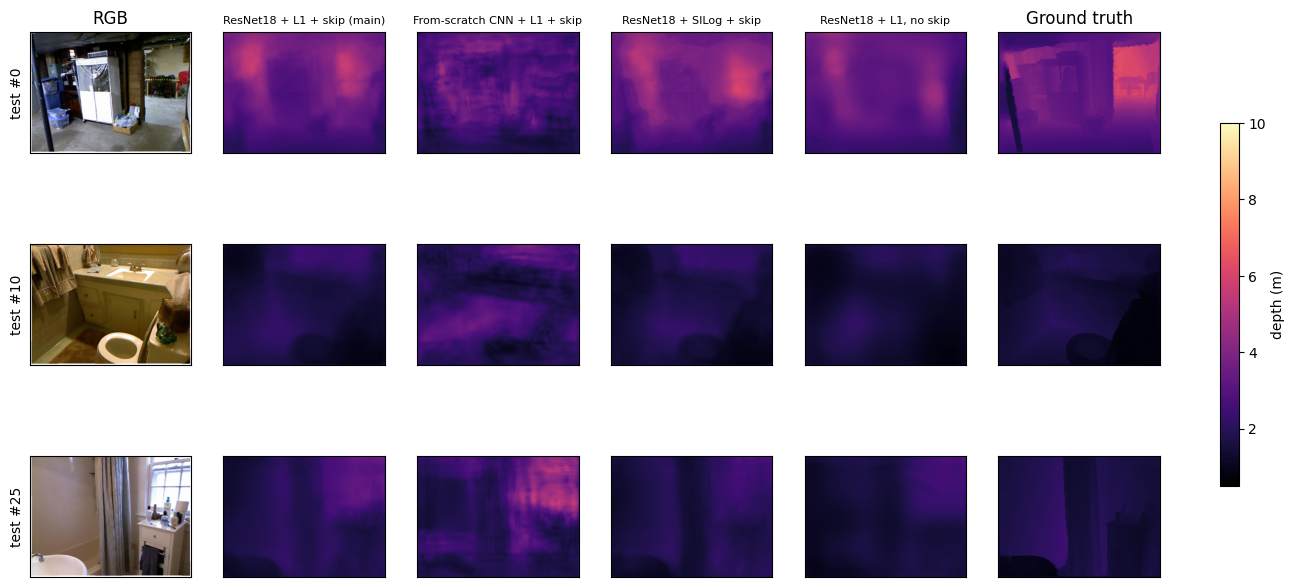

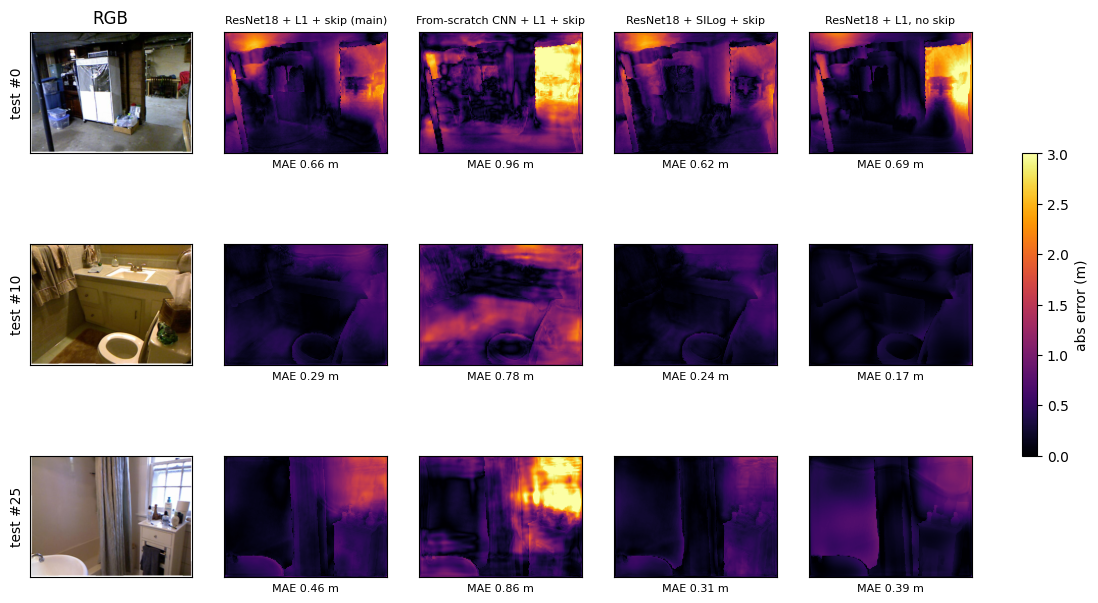

saved figures/ablation_grid.png and figures/error_grid.png


In [14]:
import os, torch, matplotlib.pyplot as plt

# set this to the folder where your .pth files are saved
CKPT_DIR = "/content/drive/MyDrive/CSE573"

os.makedirs("figures", exist_ok=True)
viz_cfg = Config()

# the configs and their checkpoint filenames (same naming as training)
CONFIGS = {
    "ResNet18 + L1 + skip (main)":  dict(backbone="resnet18", pretrained=True,  loss="l1",    use_skip=True),
    "From-scratch CNN + L1 + skip": dict(backbone="simple",   pretrained=False, loss="l1",    use_skip=True),
    "ResNet18 + SILog + skip":      dict(backbone="resnet18", pretrained=True,  loss="silog", use_skip=True),
    "ResNet18 + L1, no skip":       dict(backbone="resnet18", pretrained=True,  loss="l1",    use_skip=False),
}
def ckpt_path(ov):
    return os.path.join(CKPT_DIR, f"ckpt_{ov['backbone']}_{ov['loss']}_skip{int(ov['use_skip'])}.pth")

# load each model from its saved checkpoint
loaded = {}
for name, ov in CONFIGS.items():
    path = ckpt_path(ov)
    assert os.path.exists(path), f"checkpoint not found: {path}\nFix CKPT_DIR or the filename."
    cfg_i = Config(**ov)
    model_i = build_model(cfg_i)
    ck = torch.load(path, map_location=cfg_i.device)
    model_i.load_state_dict(ck["model"]); model_i.to(cfg_i.device).eval()
    loaded[name] = (model_i, cfg_i)
    print(f"loaded {os.path.basename(path):<34} val RMSE {ck['val']['rmse']:.4f}")

# run every model on one test sample, return dict of prediction tensors
test_ds = NYUDepthDataset(split["test"], viz_cfg, train=False)
def predict_all(rgb):
    outs = {}
    for name, (m, c) in loaded.items():
        with torch.no_grad():
            p = m(rgb.unsqueeze(0).to(c.device))[0]
        outs[name] = _match_size(p.unsqueeze(0), torch.zeros(1, 1, *viz_cfg.depth_size)).squeeze(0)
    return outs

idxs = [0, 10, 25]
names = list(CONFIGS)
dmin, dmax = viz_cfg.min_depth, viz_cfg.max_depth
err_max = 3.0                                       # clip error colormap at 3 m for fair comparison

# prediction grid: RGB | each config | ground truth
ncols = 2 + len(names)
fig, ax = plt.subplots(len(idxs), ncols, figsize=(2.6*ncols, 2.6*len(idxs)))
if len(idxs) == 1: ax = ax[None, :]
for r, i in enumerate(idxs):
    rgb, depth = test_ds[i]; preds = predict_all(rgb)
    ax[r,0].imshow(_denorm_rgb(rgb)); ax[r,0].set_ylabel(f"test #{i}")
    if r == 0: ax[r,0].set_title("RGB")
    for c, nm in enumerate(names, 1):
        ax[r,c].imshow(preds[nm][0].cpu(), cmap="magma", vmin=dmin, vmax=dmax)
        if r == 0: ax[r,c].set_title(nm, fontsize=8)
    im = ax[r,-1].imshow(depth[0].cpu(), cmap="magma", vmin=dmin, vmax=dmax)
    if r == 0: ax[r,-1].set_title("Ground truth")
    for c in range(ncols): ax[r,c].set_xticks([]); ax[r,c].set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.015, label="depth (m)")
fig.savefig("figures/ablation_grid.png", bbox_inches="tight", dpi=130); plt.show()

# error grid: RGB | |prediction - ground truth| per config
ncols = 1 + len(names)
fig, ax = plt.subplots(len(idxs), ncols, figsize=(2.6*ncols, 2.6*len(idxs)))
if len(idxs) == 1: ax = ax[None, :]
for r, i in enumerate(idxs):
    rgb, depth = test_ds[i]; preds = predict_all(rgb)
    ax[r,0].imshow(_denorm_rgb(rgb)); ax[r,0].set_ylabel(f"test #{i}")
    if r == 0: ax[r,0].set_title("RGB")
    for c, nm in enumerate(names, 1):
        err = (preds[nm][0].cpu() - depth[0].cpu()).abs()          # per-pixel absolute error (m)
        im = ax[r,c].imshow(err, cmap="inferno", vmin=0, vmax=err_max)
        if r == 0: ax[r,c].set_title(nm, fontsize=8)
        ax[r,c].set_xlabel(f"MAE {err.mean():.2f} m", fontsize=8)
    for c in range(ncols): ax[r,c].set_xticks([]); ax[r,c].set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.015, label="abs error (m)")
fig.savefig("figures/error_grid.png", bbox_inches="tight", dpi=130); plt.show()
print("saved figures/ablation_grid.png and figures/error_grid.png")